In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import sys
sys.path.append("..")

from larger_than_life import generate_neighborhood_matrix

In [5]:
types_ls = ["NM", "NN", "NC", "NB", "ND", "N+", "NX", "N*", "N#"]
names = ["Moore", "Von Neumann", "Circle", "Checkerboard", "Aligned Checkerboard", "Cross", "Saltire", "Star", "Hash"]

plt.figure(figsize=(72+1, 32+1), dpi=200)

for j, k in enumerate([1, 2, 3, 4]):
    for i, n in enumerate(types_ls):
        plt.subplot(4, 9, 9*j + i + 1)
        
        neighborhood = np.pad(generate_neighborhood_matrix(n, k), (8-k, 8-k)).astype(int)
        neighborhood[neighborhood.shape[0]//2, neighborhood.shape[0]//2] = -1
        sns.heatmap(neighborhood, cmap='RdBu', linewidths=1, linecolor="#ffffff", cbar=False, vmax=1.5, vmin=-1.5)
        plt.xticks([]); plt.yticks([]);
        
        if i == 0:
            plt.ylabel(f"$r = {k}$", fontdict={"size": 60})
        if j == 0:
            plt.title(names[i].replace(' ', "\n"), fontdict={"size": 60}, loc="left")

plt.tight_layout(pad=6)

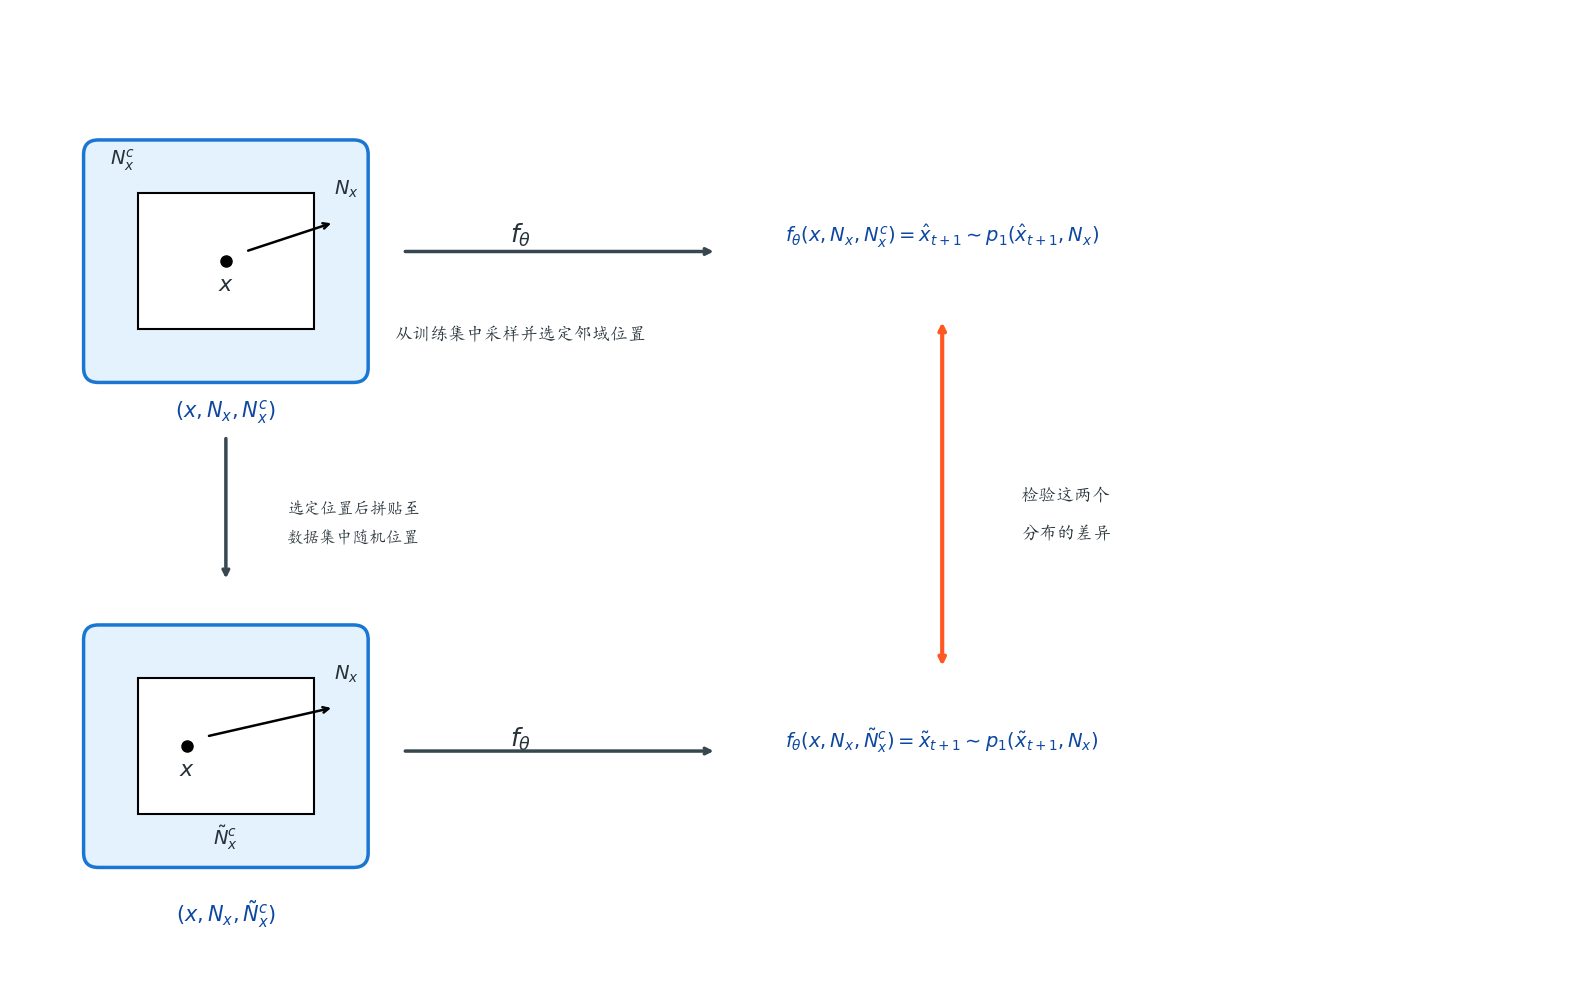

整洁美观的图表已保存！


In [29]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

plt.rcParams['font.family'] = 'Kaiti'

fig, ax = plt.subplots(1, 1, figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis('off')

# 颜色方案 - 更专业
colors = {
    'box_bg': '#E3F2FD',
    'box_border': '#1976D2',
    'arrow': '#37474F',
    'text': '#263238',
    'math': '#0D47A1',
    'accent': '#FF5722'
}

# ========== 上方方框 ==========
box1 = FancyBboxPatch((0.8, 6.2), 2.8, 2.4, boxstyle="round,pad=0.05,rounding_size=0.15",
                       facecolor=colors['box_bg'], edgecolor=colors['box_border'], linewidth=2.5)
ax.add_patch(box1)

# 内部小方框
inner_box1 = patches.Rectangle((1.3, 6.7), 1.8, 1.4, linewidth=1.5, 
                                edgecolor='black', facecolor='white')
ax.add_patch(inner_box1)

# 中心点 x
ax.plot(2.2, 7.4, 'ko', markersize=8)
ax.text(2.2, 7.1, r'$x$', fontsize=16, ha='center', color=colors['text'], fontweight='bold')

# Nx^c 标签 (左上角)
ax.text(1.15, 8.4, r'$N_x^c$', fontsize=14, ha='center', color=colors['text'])

# 箭头指向 Nx
ax.annotate('', xy=(3.3, 7.8), xytext=(2.4, 7.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.8))
ax.text(3.3, 8.1, r'$N_x$', fontsize=14, ha='left', color=colors['text'])

# ========== 上方公式 ==========
ax.text(5.2, 7.6, r'$f_\theta$', fontsize=18, ha='center', color=colors['text'], fontweight='bold')
ax.annotate('', xy=(7.2, 7.5), xytext=(4.0, 7.5),
            arrowprops=dict(arrowstyle='->', color=colors['arrow'], lw=2.5))

formula1 = r'$f_\theta(x, N_x, N_x^c) = \hat{x}_{t+1} \sim p_1(\hat{x}_{t+1}, N_x)$'
ax.text(9.5, 7.6, formula1, fontsize=14, ha='center', color=colors['math'])

# ========== 左侧中文说明 ==========
ax.text(5.2, 6.6, '从训练集中采样并选定邻域位置', fontsize=13, ha='center', color=colors['text'])
ax.text(2.2, 5.8, r'$(x, N_x, N_x^c)$', fontsize=15, ha='center', color=colors['math'], fontweight='bold')

# ========== 中间向下箭头 ==========
ax.annotate('', xy=(2.2, 5.6), xytext=(2.2, 4.1),
            arrowprops=dict(arrowstyle='<-', color=colors['arrow'], lw=2.5))

# ========== 中间说明 ==========
ax.text(3.5, 4.8, '选定位置后拼贴至', fontsize=12, ha='center', color=colors['text'])
ax.text(3.5, 4.5, '数据集中随机位置', fontsize=12, ha='center', color=colors['text'])

# ========== 下方方框 ==========
box2 = FancyBboxPatch((0.8, 1.2), 2.8, 2.4, boxstyle="round,pad=0.05,rounding_size=0.15",
                       facecolor=colors['box_bg'], edgecolor=colors['box_border'], linewidth=2.5)
ax.add_patch(box2)

# 内部小方框
inner_box2 = patches.Rectangle((1.3, 1.7), 1.8, 1.4, linewidth=1.5, 
                                edgecolor='black', facecolor='white')
ax.add_patch(inner_box2)

# 中心点 x
ax.plot(1.8, 2.4, 'ko', markersize=8)
ax.text(1.8, 2.1, r'$x$', fontsize=16, ha='center', color=colors['text'], fontweight='bold')

# Nx^c 标签（波浪线，在下方）
ax.text(2.2, 1.4, r'$\tilde{N}_x^c$', fontsize=14, ha='center', color=colors['text'])

# 箭头
ax.annotate('', xy=(3.3, 2.8), xytext=(2.0, 2.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.8))
ax.text(3.3, 3.1, r'$N_x$', fontsize=14, ha='left', color=colors['text'])

# 底部标注
ax.text(2.2, 0.6, r'$(x, N_x, \tilde{N}_x^c)$', fontsize=15, ha='center', color=colors['math'], fontweight='bold')

# ========== 下方公式 ==========
ax.text(5.2, 2.4, r'$f_\theta$', fontsize=18, ha='center', color=colors['text'], fontweight='bold')
ax.annotate('', xy=(7.2, 2.35), xytext=(4.0, 2.35),
            arrowprops=dict(arrowstyle='->', color=colors['arrow'], lw=2.5))

formula2 = r'$f_\theta(x, N_x, \tilde{N}_x^c) = \tilde{x}_{t+1} \sim p_1(\tilde{x}_{t+1}, N_x)$'
ax.text(9.5, 2.4, formula2, fontsize=14, ha='center', color=colors['math'])

# ========== 右侧大箭头和说明 ==========
# 从上方公式指向下方公式的大箭头
ax.annotate('', xy=(9.5, 3.2), xytext=(9.5, 6.8),
            arrowprops=dict(arrowstyle='<->', color=colors['accent'], lw=3))

# 右侧文字说明（水平放置更美观）
ax.text(10.3, 5.0, '检验这两个', fontsize=13, ha='left', va='center', color=colors['text'])
ax.text(10.3, 4.6, '分布的差异', fontsize=13, ha='left', va='center', color=colors['text'])

plt.tight_layout()
# plt.savefig('/mnt/okcomputer/output/clean_diagram.png', dpi=250, bbox_inches='tight', 
#             facecolor='white', edgecolor='none')
plt.show()
print("整洁美观的图表已保存！")
